# 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import re
import seaborn as sns
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# 2. Data Preprocessing




In [2]:
def clean_text(text):
    """Clean text for BERT inspired by the provided notebook."""
    text = str(text).lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [3]:
cols = ['id', 'entity', 'sentiment', 'text']
train_df = pd.read_csv('twitter_training.csv', names=cols).dropna(subset=['text'])
val_full_df = pd.read_csv('twitter_validation.csv', names=cols).dropna(subset=['text'])

train_df['text'] = train_df['text'].apply(clean_text)
val_full_df['text'] = val_full_df['text'].apply(clean_text)

label_map = {val: i for i, val in enumerate(train_df['sentiment'].unique())}
train_df['label'] = train_df['sentiment'].map(label_map)
val_full_df['label'] = val_full_df['sentiment'].map(label_map)

val_df, test_df = train_test_split(val_full_df, test_size=0.5, random_state=42, stratify=val_full_df['label'])

print(f"Data Loaded. Classes: {label_map}")

Data Loaded. Classes: {'Positive': 0, 'Neutral': 1, 'Negative': 2, 'Irrelevant': 3}


# 3. Tokenization and Dataset

In [4]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

class TwitterDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        encoding = tokenizer(
            str(self.texts[item]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


# 4. Training Functions

In [5]:
def train_epoch(model, dataloader, optimizer, scheduler):

    model.train()
    total_loss = 0

    for batch in dataloader:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids,
            attention_mask=mask,
            labels=labels
        )

        loss = outputs.loss

        loss.backward()

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


# 5. Evaluation Function

In [6]:
def evaluate(model, dataloader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for batch in dataloader:

            input_ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)

            outputs = model(input_ids, attention_mask=mask)

            preds = torch.argmax(outputs.logits, dim=1)

            y_pred.extend(preds.cpu().numpy())
            y_true.extend(batch["labels"].numpy())

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    print("\nAccuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_map.keys(),
        yticklabels=label_map.keys()
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# 6. EXPERIMENT FUNCTION

In [7]:
def run_experiment(model_name, mode="full_finetune"):

    print("\n==============================")
    print("MODEL:", model_name)
    print("MODE :", mode)
    print("==============================")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(label_map)
    )

    # FREEZING STRATEGIES
    if mode == "freeze_all":

        for param in model.base_model.parameters():
            param.requires_grad = False

    elif mode == "fine_tune_last_2":

        for param in model.base_model.parameters():
            param.requires_grad = False

        if hasattr(model.base_model, "encoder"):
            for layer in model.base_model.encoder.layer[-2:]:
                for param in layer.parameters():
                    param.requires_grad = True

    model.to(device)

    # DATALOADERS
    train_loader = DataLoader(
        TwitterDataset(train_df["text"], train_df["label"], tokenizer),
        batch_size=16,
        shuffle=True
    )

    val_loader = DataLoader(
        TwitterDataset(val_df["text"], val_df["label"], tokenizer),
        batch_size=16
    )

    test_loader = DataLoader(
        TwitterDataset(test_df["text"], test_df["label"], tokenizer),
        batch_size=16
    )

    optimizer = AdamW(model.parameters(), lr=2e-5)

    total_steps = len(train_loader) * 2

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )

    # TRAINING
    for epoch in range(2):

        model.train()
        total_loss = 0

        for batch in train_loader:

            optimizer.zero_grad()

            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                ids,
                attention_mask=mask,
                labels=labels
            )

            loss = outputs.loss

            loss.backward()

            optimizer.step()
            scheduler.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1} Loss:", total_loss/len(train_loader))

        print("Validation Performance:")
        evaluate(model, val_loader)

    print("\nFinal Test Performance:")
    evaluate(model, test_loader)


MODEL: bert-base-uncased
MODE : freeze_all


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 1.3548830221279247
Validation Performance:

Accuracy : 0.43
Precision: 0.3568911450924609
Recall   : 0.43
F1 Score : 0.388359168196921

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.54      0.49       138
           1       0.44      0.44      0.44       143
           2       0.42      0.58      0.48       133
           3       0.00      0.00      0.00        86

    accuracy                           0.43       500
   macro avg       0.32      0.39      0.35       500
weighted avg       0.36      0.43      0.39       500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

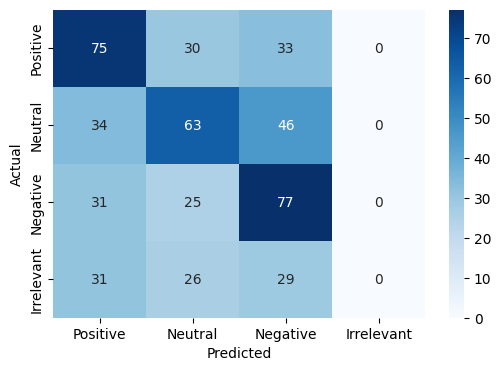

Epoch 2 Loss: 1.3387043719162812
Validation Performance:

Accuracy : 0.416
Precision: 0.3754993626587486
Recall   : 0.416
F1 Score : 0.3699164748928323

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.40      0.46       138
           1       0.47      0.35      0.40       143
           2       0.36      0.77      0.49       133
           3       0.00      0.00      0.00        86

    accuracy                           0.42       500
   macro avg       0.34      0.38      0.34       500
weighted avg       0.38      0.42      0.37       500



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

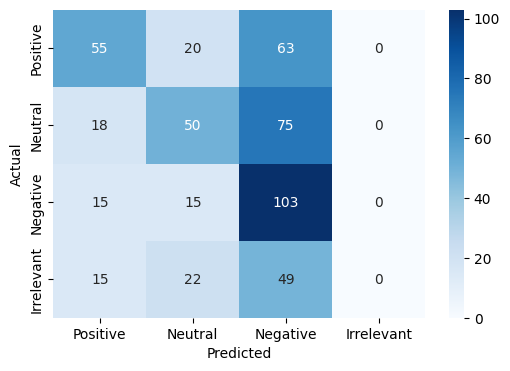


Final Test Performance:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


Accuracy : 0.408
Precision: 0.38200108909864117
Recall   : 0.408
F1 Score : 0.3613512286554883

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.33      0.40       139
           1       0.54      0.37      0.44       142
           2       0.34      0.80      0.48       133
           3       0.00      0.00      0.00        86

    accuracy                           0.41       500
   macro avg       0.34      0.37      0.33       500
weighted avg       0.38      0.41      0.36       500



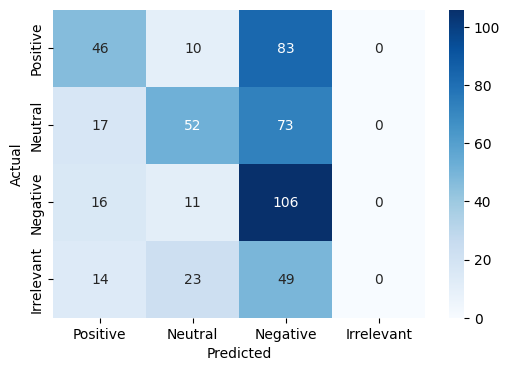


MODEL: bert-base-uncased
MODE : fine_tune_last_2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 1.029960371880918
Validation Performance:

Accuracy : 0.674
Precision: 0.6753613535623664
Recall   : 0.674
F1 Score : 0.6728932971790114

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.71      0.69       138
           1       0.61      0.64      0.63       143
           2       0.76      0.76      0.76       133
           3       0.68      0.53      0.60        86

    accuracy                           0.67       500
   macro avg       0.68      0.66      0.67       500
weighted avg       0.68      0.67      0.67       500



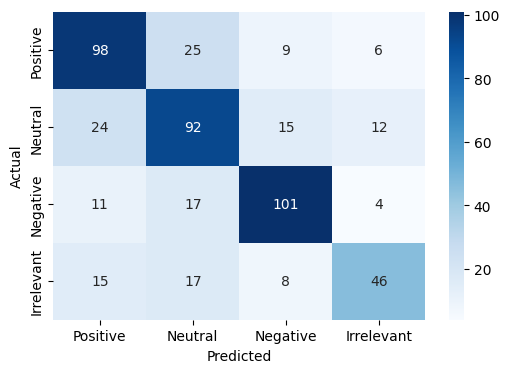

Epoch 2 Loss: 0.8685751972069612
Validation Performance:

Accuracy : 0.75
Precision: 0.7489123899934701
Recall   : 0.75
F1 Score : 0.748428502292421

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.74      0.76       138
           1       0.73      0.69      0.71       143
           2       0.78      0.87      0.82       133
           3       0.69      0.69      0.69        86

    accuracy                           0.75       500
   macro avg       0.74      0.75      0.74       500
weighted avg       0.75      0.75      0.75       500



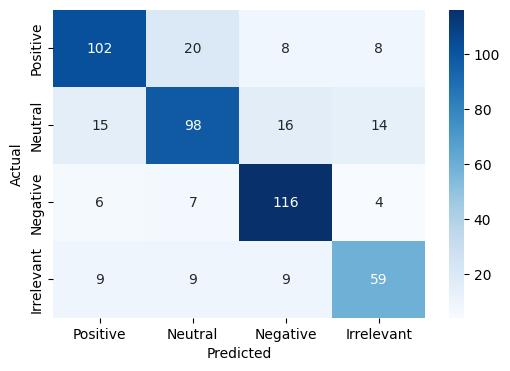


Final Test Performance:

Accuracy : 0.75
Precision: 0.7527222009675811
Recall   : 0.75
F1 Score : 0.7453610010081243

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.83      0.79       139
           1       0.80      0.68      0.73       142
           2       0.72      0.87      0.79       133
           3       0.73      0.55      0.63        86

    accuracy                           0.75       500
   macro avg       0.75      0.73      0.73       500
weighted avg       0.75      0.75      0.75       500



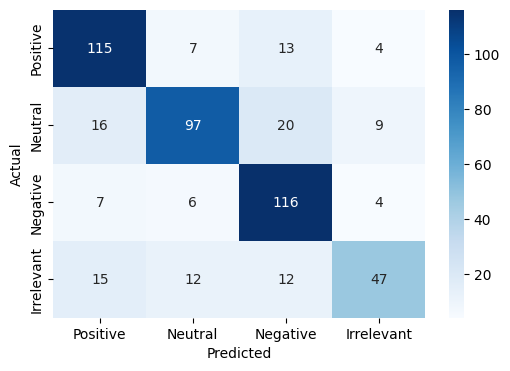


MODEL: distilbert-base-uncased
MODE : full_finetune


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 Loss: 0.7875916055891965
Validation Performance:

Accuracy : 0.908
Precision: 0.9115218341088083
Recall   : 0.908
F1 Score : 0.9081124228977017

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       138
           1       0.89      0.88      0.89       143
           2       0.95      0.94      0.95       133
           3       0.97      0.84      0.90        86

    accuracy                           0.91       500
   macro avg       0.92      0.90      0.91       500
weighted avg       0.91      0.91      0.91       500



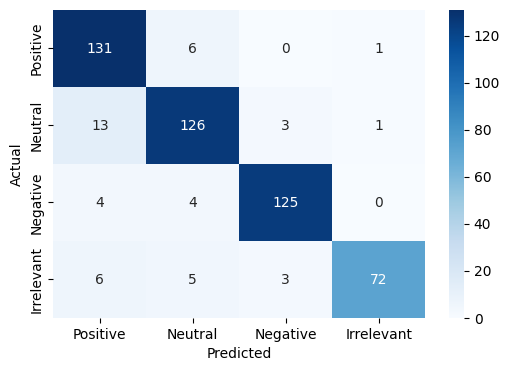

Epoch 2 Loss: 0.32129879914546333
Validation Performance:

Accuracy : 0.95
Precision: 0.9511644065862193
Recall   : 0.95
F1 Score : 0.9500236456512549

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       138
           1       0.96      0.94      0.95       143
           2       0.97      0.95      0.96       133
           3       0.97      0.91      0.94        86

    accuracy                           0.95       500
   macro avg       0.95      0.95      0.95       500
weighted avg       0.95      0.95      0.95       500



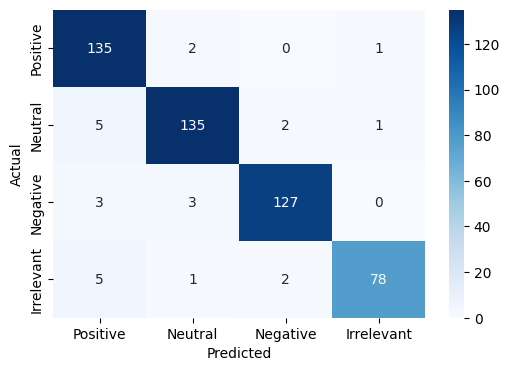


Final Test Performance:

Accuracy : 0.958
Precision: 0.9588644129833968
Recall   : 0.958
F1 Score : 0.9581040546993227

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       139
           1       0.93      0.98      0.96       142
           2       0.98      0.95      0.97       133
           3       0.93      0.95      0.94        86

    accuracy                           0.96       500
   macro avg       0.96      0.96      0.96       500
weighted avg       0.96      0.96      0.96       500



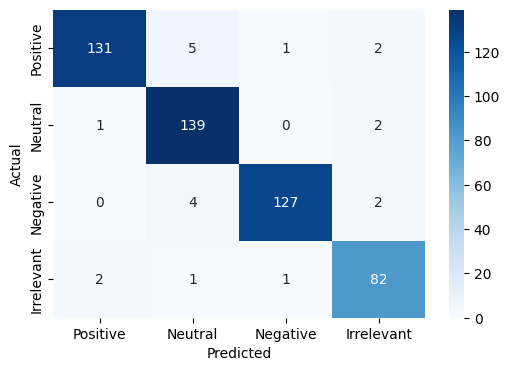

In [8]:
run_experiment("bert-base-uncased", "freeze_all")

run_experiment("bert-base-uncased", "fine_tune_last_2")

run_experiment("distilbert-base-uncased", "full_finetune")